In [138]:
from os import replace

import math
# Install a pip package in the current Jupyter kernel
import subprocess
import sys

from sympy import categories
from sympy.printing.pretty.pretty_symbology import line_width

subprocess.call([sys.executable,"-m","pip","install","numpy","gspread","oauth2client","df2gspread","pandas","matplotlib","seaborn", "pandas-profiling"])

  Using cached argparse-1.4.0-py2.py3-none-any.whl.metadata (2.8 kB)
Using cached argparse-1.4.0-py2.py3-none-any.whl (23 kB)


0

In [139]:
import math
import numpy as np
import pandas as pd
import pyreadstat
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
from pathlib import Path


In [140]:
pd.set_option('display.max_rows', 6000)
pd.set_option('display.max_columns', 6000)
pd.set_option('display.width', 6000)
pd.options.display.max_colwidth = 0

In [410]:
# Note: Rerun this cell if the data loading fails
data, meta = pyreadstat.read_sav('BD_MI_II_2024_25.sav')
len(data)

226

In [145]:
# Uncomment the next line to see the entire dataframe
#with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.precision', 3):
#    display(df)

# uncomment the next line to see only the first 5 rows (Helpful just to check the type of data on each column)
data.head()


,id,idade,nacional,nacional_other,hab,gender,gender_other,rendim,IES,IES_outra,FAC,FAC_outra,Ciclo_est,Ciclo_est_outra,Curso,Ano,regime,Satis_curso,mobilidade,mobi_reg,mobi_reg_outra,hab_aulas,hab_aulas_outro,Estatuto,estatuto_outro,trabalha,horas_traba,horas_escola,grupos_acade,assoc_est,assoc_desp,assoc_soci,nucleos,praxe,tunas,volunt,grupos_outro,grupos_fora_IES,grupos_fora_religi,grupos_fora_polit,grupos_fora_despo,grupos_fora_recreati,grupos_fora_volunt,local_resid,volunt_algum,anos_volunt,meses_volunt,horas_volunt,vol_saude,vol_educ,vol_animais,vol_desp,vol_idoso,vol_infanc,vol_acaosocial,vol_semabrigo,vol_defic,vol_forma,vol_patrim,vol_imigra,vol_toxico,vol_outras,vol_saude_at,vol_educ_at,vol_animais_at,vol_desp_at,vol_idoso_at,vol_infanc_at,vol_acaosocial_at,vol_semabrigo_at,vol_defic_at,vol_forma_at,vol_patrim_at,vol_imigra_at,vol_toxico_at,vol_outras_at,DASS_1,DASS_2,DASS_3,DASS_4,DASS_5,DASS_6,DASS_7,DASS_8,DASS_9,DASS_10,DASS_11,DASS_12,DASS_13,DASS_14,DASS_15,DASS_16,DASS_17,DASS_18,DASS_19,DASS_20,DASS_21,SP_1,SP_2,SP_3,SP_4,SP_5,SP_6,SP_7,SP_8,SP_9,SP_10,SP_11,SP_12,SP_13,SP_14,SP_15,SP_16,SP_17,SP_18,SP_19,SP_20,AC_1,AC_2,AC_3,AC_4,AC_5,AC_6,AC_7,AC_9,AC_10,AC_12,AC_13,AC_14,AC_15,AC_16,AC_17,AC_18,AC_19,AC_20,AC_21,AC_22,QVA_1,QVA_2,QVA_3,QVA_4,QVA_5,QVA_6,QVA_7,QVA_8,QVA_9,QVA_10,QVA_11,QVA_12,QVA_13
0,619.0,23.0,1.0,,3.0,1.0,,4.0,1.0,,AO11,,666666.0,Mestrado Integrado,Medicina,6.0,1.0,4.0,2.0,NaN,,NaN,,1.0,,2.0,NaN,50.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,1.0,NaN,1.0,4.0,1.0,5.0,4.0,3.0,1.0,1.0,NaN,1.0,NaN,1.0,1.0,NaN,NaN,1.0,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,1.0,NaN,NaN,NaN,,2.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,3.0,1.0,1.0,2.0,1.0,1.0,1.0,2.0,1.0,1.0,2.0,2.0,1.0,2.0,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,3.0,4.0,4.0,1.0,2.0,3.0,4.0,3.0,2.0,4.0,4.0,4.0,1.0,3.0,3.0,2.0,3.0,4.0,1.0,2.0,4.0,4.0,2.0,5.0,5.0,5.0,3.0,5.0,4.0,5.0,5.0,3.0,3.0,4.0
1,438.0,23.0,1.0,,5.0,2.0,,4.0,666666.0,Já não frequento,,,NaN,,,NaN,1.0,4.0,2.0,NaN,,NaN,,1.0,,2.0,NaN,NaN,1.0,NaN,1.0,NaN,NaN,1.0,NaN,1.0,,NaN,NaN,NaN,1.0,NaN,NaN,1.0,1.0,1.0,NaN,2.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,1.0,1.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,5.0,2.0,3.0,3.0,1.0,2.0,3.0,2.0,3.0,3.0,3.0,2.0,2.0,0.0,3.0,2.0,2.0,2.0,3.0,2.0,3.0,2.0,5.0,1.0,5.0,5.0,5.0,1.0,5.0,4.0,4.0,5.0,5.0,5.0,3.0
2,204.0,23.0,1.0,,3.0,2.0,,3.0,666666.0,Universidade Lusíada de Lisboa,,,NaN,,Comunicação é Multimedia,2023.0,1.0,3.0,2.0,NaN,,NaN,,8.0,,1.0,25.0,42.0,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,1.0,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,3.0,2.0,2.0,4.0,4.0,3.0,4.0,4.0,4.0,4.0,3.0,3.0,3.0,2.0,3.0,2.0,1.0,4.0,3.0,2.0,2.0,4.0,4.0,2.0,4.0,2.0,4.0,4.0,1.0,2.0,4.0,1.0,4.0,4.0,2.0,2.0,2.0,2.0,4.0,3.0,4.0,3.0,1.0,3.0,1.0,1.0,3.0,2.0,2.0,2.0,2.0,2.0,0.0,3.0,3.0,2.0,1.0,3.0,1.0,4.0,2.0,2.0,3.0,2.0,3.0,3.0,2.0,5.0,2.0,4.0,2.0,1.0,4.0,3.0
3,620.0,25.0,1.0,,3.0,1.0,,5.0,666666.0,Universidade Católica,,,2.0,,Mestrado em Gestão de Recursos Humanos,1.0,1.0,5.0,1.0,2.0,,1.0,,1.0,,2.0,NaN,17.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,,NaN,NaN,1.0,NaN,NaN,1.0,2.0,1.0,7.0,NaN,5.0,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,,2.0,1.0,1.0,1.0,2.0,2.0,1.0,2.0,1.0,1.0,2.0,2.0,2.0,2.0,2.0,1.0,1.0,2.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,4.0,1.0,2.0,2.0,1.0,4.0,2.0,3.0,3.0,2.0,2.0,0.0,1.0,3.0,3.0,4.0,4.0,1.0,3.0,2.0,5.0,1.0,5.0,5.0,5.0,1.0,5.0,4.0,5.0,3.0,2.0,4.0,2.0
4,384.0,19.0,1.0,,1.0,2.0,,4.0,1.0,,AO10,,1.0,,Línguas e Ralações internacionais,1.0,1.0,4.0,1.0,5.0,,5.0,,1.0,,2.0,NaN,23.0,1.0,NaN,NaN,NaN,NaN,1.0,NaN,1.0,,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,1.0,21.0,1.0,NaN,NaN

In [146]:
# get column name labels
meta.column_names_to_labels

{'id': 'id',
 'idade': 'Indica a tua idade',
 'nacional': 'Qual é a tua nacionalidade?',
 'nacional_other': '[Outro] Qual é a tua nacionalidade?',
 'hab': 'Quais as tuas habilitações literárias',
 'gender': 'Indica o género com o qual te identificas',
 'gender_other': '[Outro] Indica o género com o qual te identificas',
 'rendim': 'Indica, por favor, o nível de rendimentos do teu agregado familiar:\xa0',
 'IES': 'Qual a instituição de ensino superior que frequentas:',
 'IES_outra': '[Outro] Qual a instituição de ensino superior que frequentas:',
 'FAC': 'Indica qual a faculdade que estás a frequentar:\xa0\xa0',
 'FAC_outra': '[Outro] Indica qual a faculdade que estás a frequentar:\xa0\xa0',
 'Ciclo_est': 'Qual o ciclo de estudos que frequentas atualmente?',
 'Ciclo_est_outra': '[Outro] Qual o ciclo de estudos que frequentas atualmente?',
 'Curso': 'Qual o curso que frequentas?',
 'Ano': 'Qual o ano que frequentas?',
 'regime': 'Qual o teu regime de estudos?',
 'Satis_curso': 'Estás sat

In [147]:
# check the values for each response
meta.variable_value_labels

{'nacional': {1.0: 'Portuguesa', 666666.0: 'other'},
 'hab': {1.0: '12º ano (ensino secundário) ou equivalente',
  2.0: 'Bacharelato',
  3.0: 'Licenciatura',
  4.0: 'Pós-Graduação',
  5.0: 'Mestrado',
  6.0: 'Doutoramento'},
 'gender': {1.0: 'Masculino',
  2.0: 'Feminino',
  3.0: 'Não Binário',
  666666.0: 'other'},
 'rendim': {1.0: 'Baixo: Não chega ao final do mês',
  2.0: 'Médio-baixo: Cobrimos os gastos desde que não haja despesas extra',
  3.0: 'Médio: Vivemos confortavelmente, sem luxos',
  4.0: 'Médio: Podemos ir de férias e custear um ou outro luxo',
  5.0: 'Médio-alto: Vivemos confortavelmente',
  6.0: 'Alto: Sem preocupações económicas'},
 'IES': {1.0: 'Universidade do Porto',
  2.0: 'Instituto Politécnico do Porto',
  666666.0: 'other'},
 'FAC': {'AO10': 'Faculdade de Letras da Universidade do Porto (FLUP)',
  'AO11': 'Faculdade de Medicina da Universidade do Porto (FMUP)',
  'AO02': 'Faculdade de Arquitetura da Universidade do Porto (FAUP)',
  'AO12': 'Faculdade de Medicina

In [148]:
data.count()

id                      226
idade                   223
nacional                225
nacional_other          226
hab                     226
gender                  225
gender_other            226
rendim                  226
IES                     214
IES_outra               226
FAC                     226
FAC_outra               226
Ciclo_est               214
Ciclo_est_outra         226
Curso                   226
Ano                     212
regime                  214
Satis_curso             216
mobilidade              217
mobi_reg                92 
mobi_reg_outra          226
hab_aulas               91 
hab_aulas_outro         226
Estatuto                212
estatuto_outro          226
trabalha                203
horas_traba             58 
horas_escola            200
grupos_acade            207
assoc_est               13 
assoc_desp              11 
assoc_soci              2  
nucleos                 22 
praxe                   41 
tunas                   8  
volunt              

In [436]:
# utilities

def get_column_full_name(keyword_on_column):
    for column in data.columns:
        if keyword_on_column in column:
            return column

def plot_horizontal_distribution(results, category_names, legend_lines, legend_anchor):
    labels = list(results.keys())
    data = np.array(list(results.values()))
    data_cum = data.cumsum(axis=1)
    category_colors = plt.get_cmap('tab20c')(
        np.linspace(0.15, 0.85, data.shape[1]))

    fig, ax = plt.subplots(figsize=(12.2, 1))
    ax.invert_yaxis()
    ax.xaxis.set_visible(False)
    ax.set_xlim(0, np.sum(data, axis=1).max())

    for i, (colname, color) in enumerate(zip(category_names, category_colors)):
        widths = data[:, i]
        starts = data_cum[:, i] - widths
        ax.barh(labels, widths, left=starts, height=0.9,
                label=colname, color=color)
        xcenters = starts + widths / 2

        r, g, b, _ = color
        text_color = 'white' if r * g * b < 0.5 else 'darkgrey'
        for y, (x, c) in enumerate(zip(xcenters, widths)):
            ax.text(x, y, str(int(c)) + '%', ha='center', va='center',
                    color=text_color, fontsize='medium')
    ax.legend(ncol=int(len(category_names) / legend_lines), bbox_to_anchor=legend_anchor,
              loc='lower left', fontsize='medium')

    return fig, ax

def _define_plot_style(title='', xlabel='', ylabel='', figsize=(4, 6)):
    plt.style.use('_mpl-gallery')
    fig, ax = plt.subplots(figsize=figsize)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(True, linestyle='--', alpha=0.5)
    return fig, ax

def _save_and_display_plot(path):
    filepath = Path(path)
    plt.savefig(filepath, format='pdf', bbox_inches='tight')
    plt.show()

def plot_simple_histogram_distribution(distribution, nr_of_occurrences):
    fig, ax = _define_plot_style('')
    ax.hist(distribution, bins=nr_of_occurrences, linewidth=0.5, edgecolor="white")
    plt.show()

def plot_stylish_histogram_distribution(distribution, nr_of_occurrences, path, title, xlabel, ylabel, figsize):
    _define_plot_style(title, xlabel, ylabel, figsize=figsize)
    sns.histplot(data=distribution, bins=nr_of_occurrences, kde=True)
    _save_and_display_plot(path)

def plot_bar_graph(x_data, y_data, xlabel, ylabel, path, title='', orientation='v', figsize=(4, 6)):
    _define_plot_style(title, xlabel, ylabel, figsize=figsize)
    sns.barplot(x=x_data, y=y_data, orient=orientation)
    _save_and_display_plot(path)

def plot_donut_with_labels(data, labels, title, path):
    fig, ax = plt.subplots(figsize=(6, 3), subplot_kw=dict(aspect="equal"))
    wedges, texts = ax.pie(data, wedgeprops=dict(width=0.5), startangle=-40)

    bbox_props = dict(boxstyle="square,pad=0.3", fc="w", ec="k", lw=0.72)
    kw = dict(arrowprops=dict(arrowstyle="-"),
              bbox=bbox_props, zorder=0, va="center")

    for i, p in enumerate(wedges):
        ang = (p.theta2 - p.theta1)/2. + p.theta1
        y = np.sin(np.deg2rad(ang))
        x = np.cos(np.deg2rad(ang))
        horizontalalignment = {-1: "right", 1: "left"}[int(np.sign(x))]
        connectionstyle = f"angle,angleA=0,angleB={ang}"
        kw["arrowprops"].update({"connectionstyle": connectionstyle})
        ax.annotate(labels[i], xy=(x, y), xytext=(1.35*np.sign(x), 1.4*y),
                    horizontalalignment=horizontalalignment, **kw)

    ax.set_title(title)
    _save_and_display_plot(path)

def plot_boxplot(data, path, x=None, y=None, title='', xlabel='', ylabel=''):
    _define_plot_style(title, xlabel, ylabel)
    sns.boxplot(data=data, x=x, y=y)
    _save_and_display_plot(path)



In [412]:
# Nationality
data['nacional'].value_counts()

nacional
1.0         219
666666.0    6  
Name: count, dtype: int64

In [413]:
data['nacional_other'].value_counts()

nacional_other
               220
Brasileira     4  
Africano       1  
Moçambicana    1  
Name: count, dtype: int64

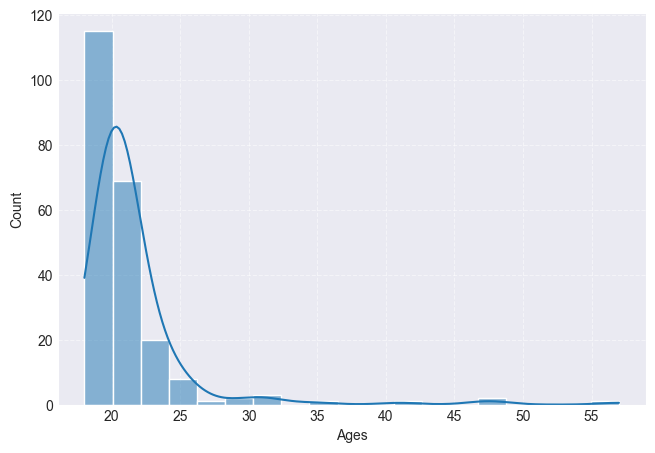

In [437]:
# age distribution
ages = data['idade']
results_size = len(ages)
occurrences = defaultdict(int)

for age in ages:
    if math.isnan(age):
        continue
    if occurrences[age]:
        occurrences[age] = occurrences[age] + 1
    else:
        occurrences[age] = 1

plot_stylish_histogram_distribution(ages, len(occurrences.keys()),
                                    '../figures/demographic_analysis/age_distribution.pdf', "", "Ages", "Count", (6, 4))

In [153]:
# gender distribution
genders = data['gender'].copy()
gender_counts = dict(genders.replace({1.0: 'Male', 2.0: 'Female', 3.0: 'Non Binary', 666666.0: 'other', math.nan: 'No Response'}).value_counts(dropna=False))
gender_counts


{'Female': 154, 'Male': 68, 'Non Binary': 3, 'No Response': 1}

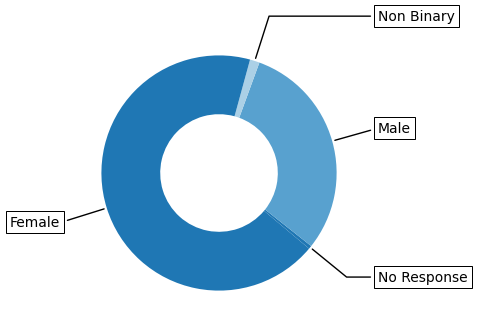

In [154]:
labels = ['No Response', 'Male', 'Non Binary', 'Female']
data = [gender_counts[v] for v in labels]
plot_donut_with_labels(data, labels, '', path='../figures/demographic_analysis/gender_distribution.pdf')


In [411]:
# Check nationality
nationalities = data['nacional'].copy()
nationalities = nationalities.replace({1.0: 'Portugal', 666666.0: 'Other', math.nan: 'No response'})

users_by_country = defaultdict(int)
for nationality in nationalities:
        if users_by_country[nationality]:
            users_by_country[nationality] = users_by_country[nationality] + 1
        else:
            users_by_country[nationality] = 1
users_by_country = dict(users_by_country.items())
users_by_country

{'Portugal': 219, 'Other': 6, 'No response': 1}

In [414]:
education = data['hab'].copy()
education_count = education.replace({1.0: 'Secondary Education', 2.0: "Bachelor's degree", 3.0: 'University degree', 4.0: 'Postgraduate', 5.0: "Master's degree", 6.0: "Doctor of Philosophy"}).value_counts()
education_count

hab
Secondary Education     139
University degree       72 
Master's degree         12 
Postgraduate            1  
Doctor of Philosophy    1  
Bachelor's degree       1  
Name: count, dtype: int64

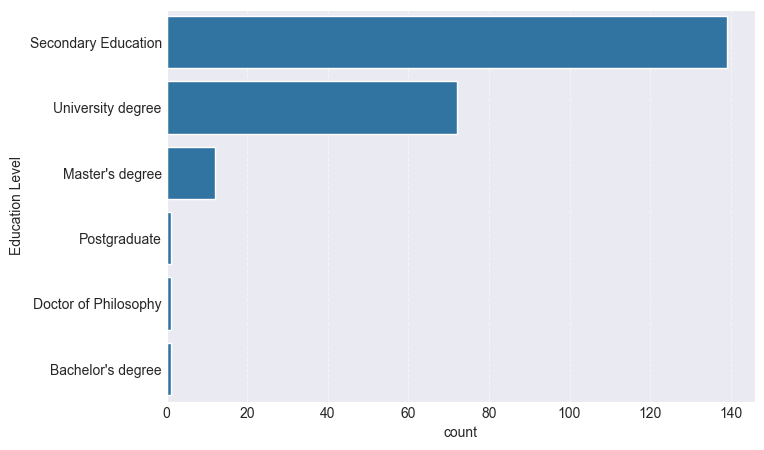

In [416]:
# education distribution

plot_bar_graph(education_count.values, education_count.index, xlabel='count', ylabel='Education Level', path='../../research_methods_practical/Figures/education_distribution.pdf', orientation='h', figsize=(6, 4))


In [417]:
# 'rendim': {1.0: 'Baixo: Não chega ao final do mês',
#            2.0: 'Médio-baixo: Cobrimos os gastos desde que não haja despesas extra',
#            3.0: 'Médio: Vivemos confortavelmente, sem luxos',
#            4.0: 'Médio: Podemos ir de férias e custear um ou outro luxo',
#            5.0: 'Médio-alto: Vivemos confortavelmente',
#            6.0: 'Alto: Sem preocupações económicas'},


income = pd.DataFrame(data=data['rendim'])
income['categories'] = income['rendim'].map({1.0: 'Low', 2.0: 'Medium-Low', 3.0: 'Medium-No Luxury', 4.0: 'Medium-Luxury', 5.0: 'Medium-High', 6.0: 'High'})
income['rendim'] = income['rendim'].astype(float)
income['categories'] = pd.Categorical(income['categories'], categories=['Low', 'Medium-Low', 'Medium-No Luxury', 'Medium-Luxury', 'Medium-High', 'High'], ordered=True)
income

,rendim,categories
0,4.0,Medium-Luxury
1,4.0,Medium-Luxury
2,3.0,Medium-No Luxury
3,5.0,Medium-High
4,4.0,Medium-Luxury
5,5.0,Medium-High
6,4.0,Medium-Luxury
7,4.0,Medium-Luxury
8,4.0,Medium-Luxury
9,6.0,High


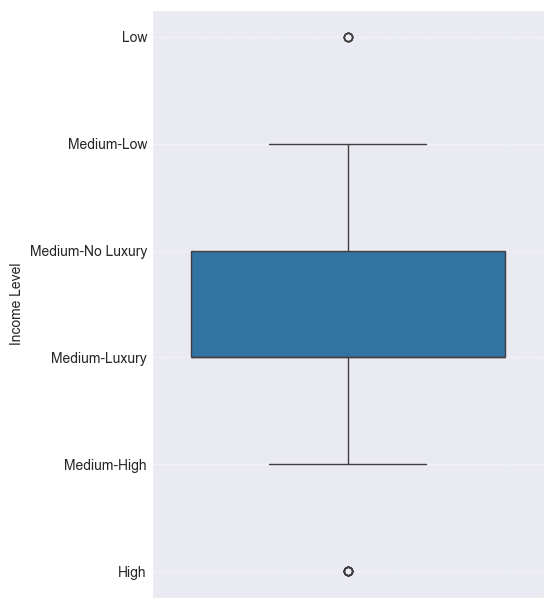

In [439]:
plot_boxplot(income, '../figures/demographic_analysis/income_distribution.pdf', x=None, y='categories', ylabel='Income Level')